In [2]:
#Uploading CSV Files
from google.colab import files
uploaded = files.upload()

In [3]:
#Installing Libraries
!pip install scikit-learn xgboost lightgbm surprise streamlit pyngrok -q

In [4]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [5]:
#Loading DATATASETS
transactions = pd.read_excel("/content/Transaction.xlsx")
users = pd.read_excel("/content/User.xlsx")
cities = pd.read_excel("/content/City.xlsx")
items = pd.read_excel("/content/Item.xlsx")
countries = pd.read_excel("/content/Country.xlsx")
continents = pd.read_excel("/content/Continent.xlsx")
regions = pd.read_excel("/content/Region.xlsx")
types = pd.read_excel("/content/Type.xlsx")
visitmode = pd.read_excel("/content/Mode.xlsx")

In [6]:
#Data Checking
transactions.head()


transactions.info()


transactions.isnull().sum()


transactions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000


In [7]:
#Data Cleaning

#Handling Missing Values
transactions.dropna(inplace=True)
users.dropna(inplace=True)

In [8]:
#Remove Duplicates Value
transactions.drop_duplicates(inplace=True)

In [9]:
df = transactions.merge(users, on='UserId', how='left')

# Rename user's location IDs for clarity
df = df.rename(columns={
    'ContinentId': 'UserContinentId',
    'RegionId': 'UserRegionId',
    'CountryId': 'UserCountryId',
    'CityId': 'UserCityId'
})

df = df.merge(items, on='AttractionId', how='left')

df = df.merge(types, on='AttractionTypeId', how='left')

# Merge with cities for attraction city details
cities_attraction = cities.rename(columns={
    'CityId': 'AttractionCityId_lookup',
    'CityName': 'AttractionCityName',
    'CountryId': 'AttractionCountryId'
})
df = df.merge(cities_attraction, left_on='AttractionCityId', right_on='AttractionCityId_lookup', how='left')

# Merge with countries for attraction country details
countries_attraction = countries.rename(columns={
    'CountryId': 'AttractionCountryId_lookup',
    'Country': 'AttractionCountryName',
    'RegionId': 'AttractionRegionId'
})
df = df.merge(countries_attraction, left_on='AttractionCountryId', right_on='AttractionCountryId_lookup', how='left')

# Merge with regions for attraction region details
regions_attraction = regions.rename(columns={
    'RegionId': 'AttractionRegionId_lookup',
    'Region': 'AttractionRegionName',
    'ContinentId': 'AttractionContinentId'
})
df = df.merge(regions_attraction, left_on='AttractionRegionId', right_on='AttractionRegionId_lookup', how='left')

# Merge with continents for attraction continent details
continents_attraction = continents.rename(columns={
    'ContinentId': 'AttractionContinentId_lookup',
    'Continent': 'AttractionContinentName'
})
df = df.merge(continents_attraction, left_on='AttractionContinentId', right_on='AttractionContinentId_lookup', how='left')


In [10]:
#Feature Engineering

#Create Seasonal Feature

def season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['VisitMonth'].apply(season)

In [11]:
# Encoding

le = LabelEncoder()

categorical_cols = [
    'VisitMode',
    'AttractionContinentName', # Changed from 'Continent'
    'AttractionRegionName',    # Changed from 'Region'
    'AttractionCountryName',   # Changed from 'Country'
    'AttractionCityName',      # Changed from 'CityName'
    'AttractionType',
    'Season'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

##EDA

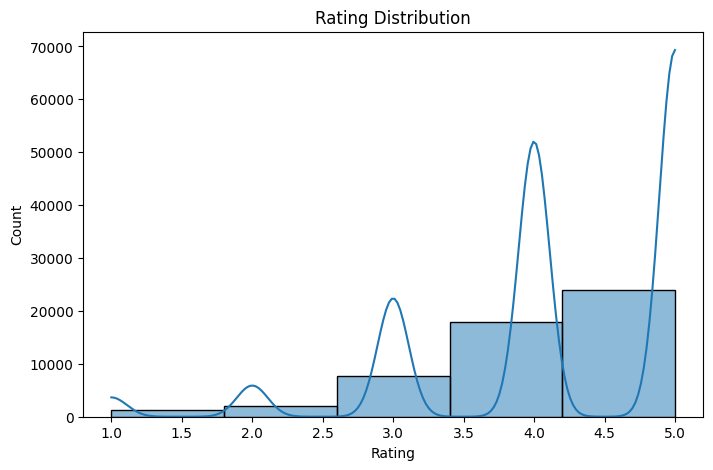

In [12]:
#Ratings Distributions

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=5, kde=True)
plt.title("Rating Distribution")
plt.show()

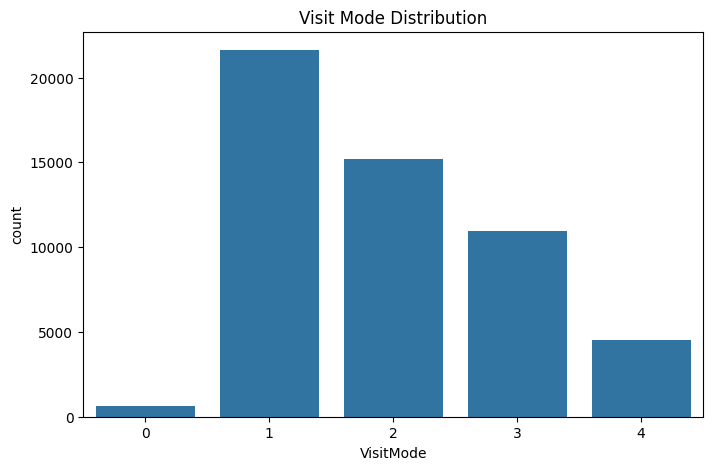

In [13]:
#Visit Mode Count

plt.figure(figsize=(8,5))
sns.countplot(x='VisitMode', data=df)
plt.title("Visit Mode Distribution")
plt.show()

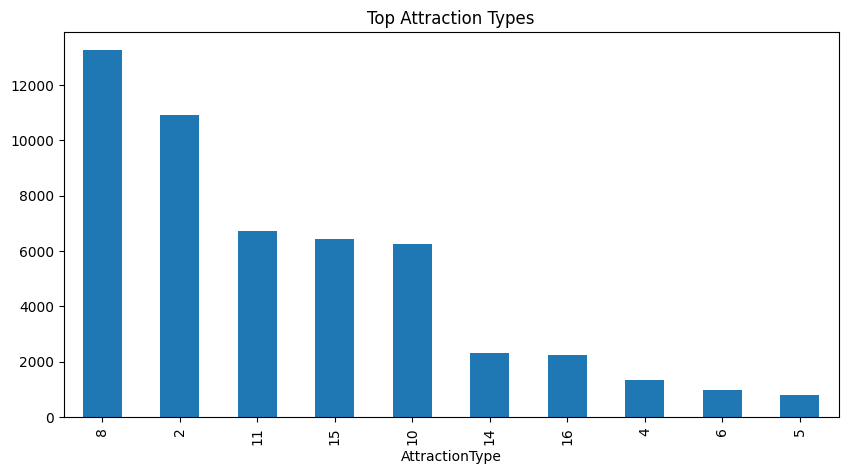

In [14]:
#Top Attraction Types

plt.figure(figsize=(10,5))
df['AttractionType'].value_counts().head(10).plot(kind='bar')
plt.title("Top Attraction Types")
plt.show()

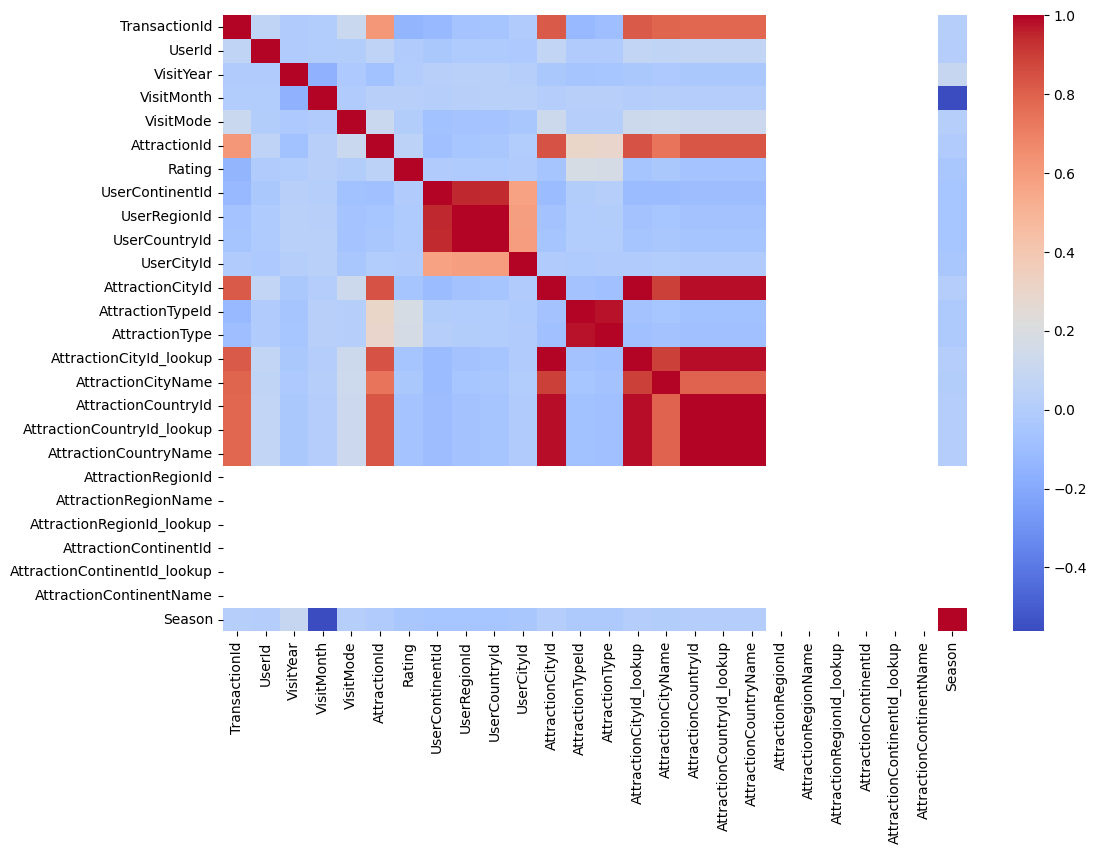

In [15]:
#Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.show()

##Regression Model

In [16]:
#Features and Target

X = df.drop(['Rating'], axis=1)
y = df['Rating']

In [17]:
#Train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Scaling


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

# Identify non-numeric columns (e.g., 'AttractionName', 'AttractionAddress')
# X_train is now guaranteed to be a DataFrame here.
non_numeric_cols = X_train.select_dtypes(include=['object']).columns

# Drop these columns from X_train and X_test
X_train = X_train.drop(columns=non_numeric_cols)
X_test = X_test.drop(columns=non_numeric_cols)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
#Train Model

regressor = RandomForestRegressor()

regressor.fit(X_train, y_train)

RandomForestRegressor()

In [20]:
#Predictions

pred = regressor.predict(X_test)

#Evaluation

###Mean Squared Error



In [21]:
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MSE: 0.839304458719063
R2 Score: 0.10884473539492912


#CLASSIFICATION MODEL

In [22]:
X = df.drop(['VisitMode'], axis=1)
y = df['VisitMode']

In [23]:
#Train Model

classifier = RandomForestClassifier()

classifier.fit(X_train, y_train)

RandomForestClassifier()

In [24]:
#Prediction

pred = classifier.predict(X_test)

#Evaluation

##Accuracy Formula

###Accuracy=
Total Predictions/
Correct Predictions
	​


In [25]:
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.47005478934441713
              precision    recall  f1-score   support

           1       0.36      0.19      0.25       257
           2       0.27      0.08      0.12       409
           3       0.28      0.17      0.21      1509
           4       0.41      0.38      0.40      3632
           5       0.54      0.68      0.60      4779

    accuracy                           0.47     10586
   macro avg       0.37      0.30      0.32     10586
weighted avg       0.44      0.47      0.45     10586



#RECOMMENDATION SYSTEM

##Collaborative Filtering

In [26]:
pivot = df.pivot_table(
    index='UserId',
    columns='Attraction',
    values='Rating'
).fillna(0)

In [27]:
#Cosine Simmilarity

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(pivot)

In [28]:
#Recommendation Function
def recommend(user_id):

    similar_users = similarity[user_id]

    similar_user_index = np.argsort(similar_users)[::-1][1:6]

    recommendations = []

    for idx in similar_user_index:
        rec = pivot.iloc[idx].sort_values(ascending=False).head(5)
        recommendations.extend(rec.index.tolist())

    return list(set(recommendations))

In [29]:
#TEST

recommend(2)

['Waterbom Bali',
 'Goa Cina Beach',
 'Balekambang Beach',
 'Coban Rondo Waterfall',
 'Jodipan Colorful Village']

#Saving Model

In [30]:
import pickle

pickle.dump(regressor, open('rating_model.pkl', 'wb'))
pickle.dump(classifier, open('visitmode_model.pkl', 'wb'))

#StreamLit App

In [35]:
%%writefile app.py


import streamlit as st
import numpy as np

# ===================================
# PAGE CONFIGURATION
# ===================================

st.set_page_config(
    page_title="Tourism Analytics",
    page_icon="🌍",
    layout="centered"
)

# ===================================
# TITLE
# ===================================

st.title("🌍 Tourism Experience Analytics")

st.write("""
This application predicts:

✔ Tourist Visit Mode
✔ Attraction Ratings
✔ Attraction Recommendations
""")

# ===================================
# SIDEBAR
# ===================================

menu = st.sidebar.selectbox(
    "Select Option",
    [
        "Home",
        "Visit Mode Prediction",
        "Rating Prediction",
        "Recommendation System"
    ]
)

# ===================================
# HOME PAGE
# ===================================

if menu == "Home":

    st.header("🏖 Tourism Analytics Project")

    st.write("""
    This project uses Machine Learning
    and Recommendation Systems to analyze
    tourism experiences.
    """)

# ===================================
# VISIT MODE PREDICTION
# ===================================

elif menu == "Visit Mode Prediction":

    st.header("🧳 Visit Mode Prediction")

    age = st.slider(
        "Enter Age",
        18,
        70,
        25
    )

    visit_month = st.slider(
        "Visit Month",
        1,
        12,
        6
    )

    rating = st.slider(
        "Previous Rating",
        1,
        5,
        4
    )

    if st.button("Predict Visit Mode"):

        # Dummy prediction logic

        if rating >= 4:
            result = "Family"

        elif rating == 3:
            result = "Friends"

        else:
            result = "Business"

        st.success(f"Predicted Visit Mode: {result}")

# ===================================
# RATING PREDICTION
# ===================================

elif menu == "Rating Prediction":

    st.header("⭐ Attraction Rating Prediction")

    attractions = st.selectbox(
        "Select Attraction Type",
        [
            "Beach",
            "Museum",
            "Park",
            "Historical Place"
        ]
    )

    visit_month = st.slider(
        "Visit Month",
        1,
        12,
        5
    )

    if st.button("Predict Rating"):

        # Dummy prediction logic

        if attractions == "Beach":
            rating = 4.7

        elif attractions == "Museum":
            rating = 4.2

        elif attractions == "Park":
            rating = 4.5

        else:
            rating = 4.3

        st.success(
            f"Predicted Rating: {rating}"
        )

# ===================================
# RECOMMENDATION SYSTEM
# ===================================

elif menu == "Recommendation System":

    st.header("🎯 Tourist Attraction Recommendations")

    preference = st.selectbox(
        "Choose Preference",
        [
            "Beach",
            "Museum",
            "Park",
            "Historical Place"
        ]
    )

    if st.button("Get Recommendations"):

        recommendations = {

            "Beach": [
                "Goa Beach",
                "Maldives",
                "Bondi Beach"
            ],

            "Museum": [
                "Louvre Museum",
                "British Museum",
                "National Museum"
            ],

            "Park": [
                "Central Park",
                "Yellowstone Park",
                "National Park"
            ],

            "Historical Place": [
                "Taj Mahal",
                "Colosseum",
                "Great Wall of China"
            ]
        }

        st.subheader("Recommended Attractions")

        for place in recommendations[preference]:

            st.write(f"✔ {place}")

# ===================================
# FOOTER
# ===================================

st.markdown("---")

st.caption("Tourism Experience Analytics System")

Writing app.py
